# Testing Autoencoder (VAE)

PCA  (2 components) — val reconstruction MSE: 0.05532
Epoch    0 | train loss = 2.7957
Epoch  500 | train loss = 1.3078
Epoch 1000 | train loss = 1.2974
Epoch 1500 | train loss = 1.3066
Epoch 2000 | train loss = 1.3228
Epoch 2500 | train loss = 1.2996
Epoch 3000 | train loss = 1.3034

VAE  (2 latent dims)  — val reconstruction MSE: 0.25187
PCA  (2 components)    — val reconstruction MSE: 0.05532


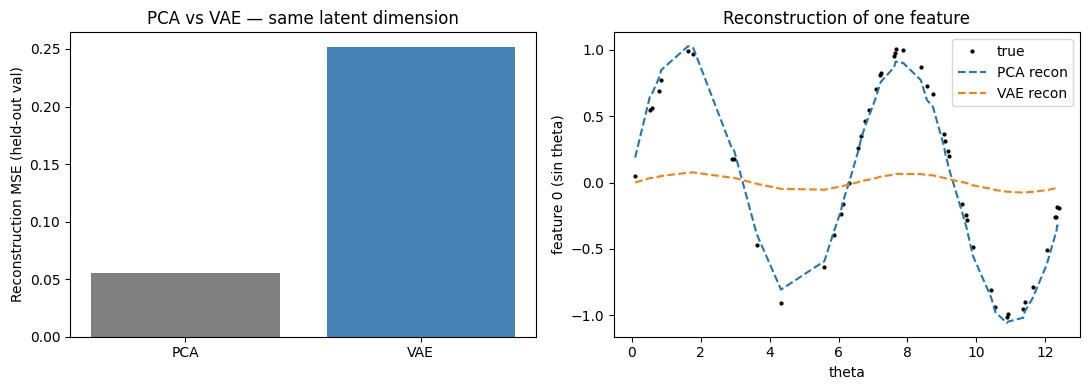

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

torch.manual_seed(0)
np.random.seed(0)

# ============================================================
# 1. Data: 1D helix embedded nonlinearly in R^5, plus noise
# ============================================================
theta = np.linspace(0, 4*np.pi, 500)
X = np.stack([
    np.sin(theta), np.cos(theta), theta/10,
    np.sin(2*theta)*0.5, np.cos(3*theta)*0.3
], axis=1).astype(np.float32)
X += 0.02 * np.random.randn(*X.shape).astype(np.float32)

X_t = torch.tensor(X)
n = X_t.shape[0]
idx = torch.randperm(n)
n_train = int(0.9 * n)
train_idx, val_idx = idx[:n_train], idx[n_train:]

X_train, X_val = X_t[train_idx], X_t[val_idx]
theta_val = theta[val_idx.numpy()]           # kept only for plotting/coloring later

n_features, latent_dim = 5, 2                 # same compressed dimension for both methods

# ============================================================
# 2. PCA baseline (fit on train, reconstruct held-out val)
# ============================================================
pca = PCA(n_components=latent_dim)
pca.fit(X_train.numpy())                       # PCA only ever sees training data

X_val_pca_scores = pca.transform(X_val.numpy())
X_val_pca_recon  = pca.inverse_transform(X_val_pca_scores)
pca_mse = np.mean((X_val.numpy() - X_val_pca_recon)**2)

print(f"PCA  ({latent_dim} components) — val reconstruction MSE: {pca_mse:.5f}")

# ============================================================
# 3. VAE model
# ============================================================
class VAE(nn.Module):
    def __init__(self, n_features, latent_dim, hidden=32):
        super().__init__()
        self.encoder_body = nn.Sequential(nn.Linear(n_features, hidden), nn.ReLU())
        self.to_mu     = nn.Linear(hidden, latent_dim)
        self.to_logvar = nn.Linear(hidden, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, n_features)
        )

    def forward(self, x):
        h = self.encoder_body(x)
        mu, logvar = self.to_mu(h), self.to_logvar(h)
        eps = torch.randn_like(mu)
        z = mu + torch.exp(0.5 * logvar) * eps
        return self.decoder(z), mu, logvar

def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    recon = torch.sum((x - x_hat)**2)
    kl = 0.5 * torch.sum(mu**2 + logvar.exp() - 1 - logvar)
    return recon + beta * kl

# ============================================================
# 4. Train the VAE
# ============================================================
model = VAE(n_features=n_features, latent_dim=latent_dim, hidden=32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
beta = 1.0
n_epochs = 3000

for epoch in range(n_epochs + 1):
    model.train()
    x_hat, mu, logvar = model(X_train)
    loss = vae_loss(X_train, x_hat, mu, logvar, beta=beta) / X_train.shape[0]

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | train loss = {loss.item():.4f}")

# ============================================================
# 5. Evaluate VAE reconstruction on the SAME held-out val set
#    Use z = mu (deterministic) -- fair comparison against PCA,
#    which is also a deterministic reconstruction.
# ============================================================
model.eval()
with torch.no_grad():
    h_val = model.encoder_body(X_val)
    mu_val = model.to_mu(h_val)                # deterministic code, no sampling
    X_val_vae_recon = model.decoder(mu_val)

vae_mse = torch.mean((X_val - X_val_vae_recon)**2).item()
print(f"\nVAE  ({latent_dim} latent dims)  — val reconstruction MSE: {vae_mse:.5f}")
print(f"PCA  ({latent_dim} components)    — val reconstruction MSE: {pca_mse:.5f}")

# ============================================================
# 6. Visual comparison
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['PCA', 'VAE'], [pca_mse, vae_mse], color=['gray', 'steelblue'])
axes[0].set_ylabel('Reconstruction MSE (held-out val)')
axes[0].set_title('PCA vs VAE — same latent dimension')

# Compare one feature (e.g. feature 0 = sin(theta)) as a function of theta
sort_idx = np.argsort(theta_val)
axes[1].plot(theta_val[sort_idx], X_val.numpy()[sort_idx, 0], 'k.', label='true', markersize=4)
axes[1].plot(theta_val[sort_idx], X_val_pca_recon[sort_idx, 0], label='PCA recon', linestyle='--')
axes[1].plot(theta_val[sort_idx], X_val_vae_recon.numpy()[sort_idx, 0], label='VAE recon', linestyle='--')
axes[1].set_xlabel('theta'); axes[1].set_ylabel('feature 0 (sin theta)')
axes[1].legend(); axes[1].set_title('Reconstruction of one feature')

plt.tight_layout()
plt.show()
